##Object Detection using YOLOv8
Project Title

Aerial Object Classification & Detection

Introduction

In the previous notebooks we developed models for image classification.

However, classification only tells what object is present in an image.

To improve the system, we now implement object detection, which identifies:


*   what object is present
*   where the object is located in the image





For this task we use YOLOv8 (You Only Look Once), a state-of-the-art object detection model.

YOLOv8 is capable of detecting multiple objects in real time and drawing bounding boxes around them.

##Import Libraries

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.2 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Check GPU Availability

In [5]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

GPU Available: True
Device: Tesla T4


#Dataset Path

In [6]:
dataset_path = "/content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/data.yaml"

In [7]:
print("Dataset exists:", os.path.exists(dataset_path))

Dataset exists: True


##Load YOLOv8 Model

We will use the YOLOv8 Nano model, which is lightweight and suitable for quick training.

In [8]:
model = YOLO("yolov8n.pt")

##Train YOLOv8 Model

The model will be trained on the object detection dataset.

In [11]:
model.train(
    data=dataset_path,
    epochs=5,          # optimized for faster training
    imgsz=640,
    batch=16,
    device=0            # GPU
)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78ef35257fe0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

##Validate Model

In [12]:
model.val()

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.2 ms, read: 15.8±7.9 MB/s, size: 28.0 KB)
val: Scanning /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/valid/labels.cache... 448 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 448/448 144.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 3.5it/s 7.9s
                   all        448        663      0.835      0.663      0.755      0.443
                  Bird        217        414      0.833      0.483      0.637      0.347
                 drone        225        249      0.837      0.843      0.872      0.538
Speed: 2.4ms preprocess, 4.1ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78f0741cdd00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

##Run Detection on Test Images


image 1/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg: 640x640 1 Bird, 11.2ms
image 2/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/00188d7f40a84793_jpg.rf.7f9da2b662dc236fbdcc1f22d8e0983e.jpg: 640x640 1 Bird, 7.2ms
image 3/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/0028adf0e92c3da2_jpg.rf.48c97d30547a46e83abcbd1bf801c72f.jpg: 640x640 4 Birds, 28.8ms
image 4/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/00347cbbeed4bedb_jpg.rf.aa19c9a7a22d76f8539ca12ac7cb82d5.jpg: 640x640 1 Bird, 11.0ms
image 5/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/004cc8de466969bc_jpg.rf.ca1ffa31f30a92a3987e689583983973.jpg: 640x640 1 Bird, 8.8ms
image 6/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/006ce62a72d

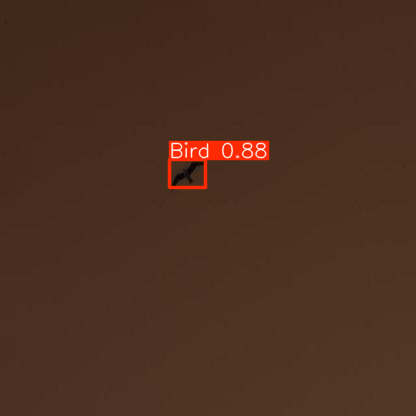

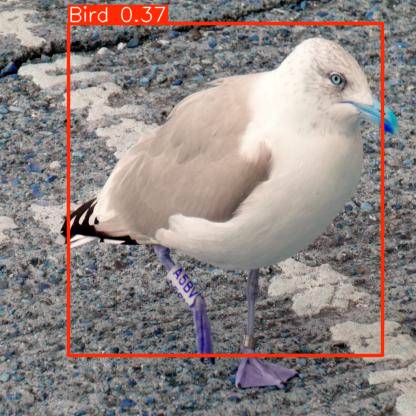

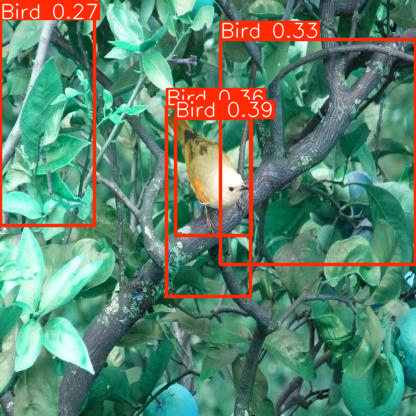

In [17]:
from IPython.display import display
from PIL import Image as PILImage

# Run prediction
results = model.predict(
    source="/content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images",
    conf=0.25
)

# Display results
for r in results[:3]:   # show first 3 images only
    img = r.plot()
    display(PILImage.fromarray(img))

##Save Trained Model

In [20]:
import os
import shutil

base_path = "runs/detect"

# get latest training folder
folders = [f for f in os.listdir(base_path) if f.startswith("train")]
latest_folder = sorted(folders)[-1]

best_model_path = os.path.join(base_path, latest_folder, "weights", "best.pt")

print("Using model from:", best_model_path)

shutil.copy(
    best_model_path,
    "/content/drive/MyDrive/Aerial_Object_Project/models/yolov8_model.pt"
)

print("Model saved successfully!")

Using model from: runs/detect/train2/weights/best.pt
Model saved successfully!


##Load Model for Inference

In [21]:
model = YOLO("/content/drive/MyDrive/Aerial_Object_Project/models/yolov8_model.pt")

results = model.predict(
    source="/content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images",
    conf=0.25,
    save=True
)


image 1/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg: 640x640 1 Bird, 8.1ms
image 2/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/00188d7f40a84793_jpg.rf.7f9da2b662dc236fbdcc1f22d8e0983e.jpg: 640x640 1 Bird, 7.2ms
image 3/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/0028adf0e92c3da2_jpg.rf.48c97d30547a46e83abcbd1bf801c72f.jpg: 640x640 4 Birds, 28.1ms
image 4/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/00347cbbeed4bedb_jpg.rf.aa19c9a7a22d76f8539ca12ac7cb82d5.jpg: 640x640 1 Bird, 7.6ms
image 5/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/004cc8de466969bc_jpg.rf.ca1ffa31f30a92a3987e689583983973.jpg: 640x640 1 Bird, 9.0ms
image 6/224 /content/drive/MyDrive/Aerial_Object_Project/object_detection_Dataset/test/images/006ce62a72df4

##Conclusion

In this notebook, we implemented YOLOv8 object detection to detect birds and drones in aerial images.

The model is capable of:


*   Detecting multiple objects
*   Drawing bounding boxes
*   Classifying each object

This completes the object detection pipeline of the project.